# 🩺 피부 질환 분류 — ConvNeXt-Small 전이학습 파이프라인

## 전체 흐름 개요

```
STEP 1  ─ 환경 확인             PyTorch 임포트 · GPU(CUDA) 사용 가능 여부 체크
STEP 2  ─ 데이터 수집           icrawler BingImageCrawler로 5종 피부 질환 이미지 크롤링
STEP 3  ─ 데이터 분리           수집 이미지를 train / test 폴더로 분리
STEP 4  ─ 라이브러리 임포트     딥러닝 학습에 필요한 모든 패키지 일괄 임포트
STEP 5  ─ 원본 이미지 탐색      크기·채널 등 메타데이터 확인
STEP 6  ─ 전처리 파이프라인     Resize · Augmentation · ToTensor · Normalize 정의
STEP 7  ─ 데이터셋 구성         ImageFolder 로 폴더 구조에서 클래스 자동 인식
STEP 8  ─ DataLoader + 시각화   미니배치 로더 생성 · 역정규화 이미지 출력
STEP 9  ─ 사전학습 모델 로드    ConvNeXt-Small (ImageNet1K) 불러오기
STEP 10 ─ Feature Extraction    Backbone 동결 → 분류 헤드만 5-클래스로 교체
STEP 11 ─ Feature Extraction 학습  classifier[2] 만 학습 · TensorBoard 기록
STEP 12 ─ Feature Extraction 평가  테스트셋 정확도 계산 · 배치 시각화
STEP 13 ─ Fine-Tuning           features[6~7] + classifier[2] 함께 학습 · 베스트 모델 저장
STEP 14 ─ Grad-CAM              예측 근거 히트맵 시각화 라이브러리 임포트
```

| 클래스  | 질환명     | 설명                    |
| ------- | ---------- | ----------------------- |
| acne    | 여드름     | 모낭 및 피지선 염증     |
| eksim   | 습진       | 만성 염증성 피부질환    |
| herpes  | 헤르페스   | 바이러스성 수포 피부염  |
| panu    | 어루러기   | 진균(곰팡이) 감염       |
| rosacea | 주사(酒糟) | 안면 홍조·구진 피부질환 |


---

## STEP 1 — 환경 확인

> **목적** : PyTorch가 올바르게 설치되어 있는지, GPU(CUDA)를 사용할 수 있는지 확인합니다.

- `import torch` → PyTorch 최상위 패키지 로드 (텐서 연산 · 자동 미분 · CUDA 지원)
- `torch.cuda.is_available()` → `True` 이면 GPU 학습 가능 / `False` 이면 CPU 전용


In [2]:
# ══════════════════════════════════════════════════════════════════════
# [셀 1] PyTorch 핵심 라이브러리 임포트
# ══════════════════════════════════════════════════════════════════════
# torch는 PyTorch의 최상위 패키지입니다.
# 주요 기능:
#  1) 텐서(Tensor): NumPy 배열과 유사하지만 GPU 연산을 지원하는 다차원 배열
#  2) CUDA 지원: torch.cuda.* API로 GPU 자원 관리 및 GPU 연산 가속
#  3) 자동 미분(autograd): requires_grad=True인 텐서에 대해
#     역전파(backpropagation) 시 기울기(gradient)를 자동으로 계산
#  4) 직렬화: torch.save / torch.load로 모델 가중치 저장·로드
import torch


In [3]:
# ══════════════════════════════════════════════════════════════════════
# [셀 2] GPU(CUDA) 사용 가능 여부 확인
# ══════════════════════════════════════════════════════════════════════
# torch.cuda.is_available():
#  - NVIDIA GPU 드라이버 + CUDA 런타임이 설치되어 있고,
#    PyTorch가 CUDA 빌드 버전인 경우 True 반환
#  - False이면 CPU만 사용 → 학습 속도가 크게 느려질 수 있음
# 결과가 False라면:
#  - CUDA Toolkit 버전과 PyTorch 버전이 일치하는지 확인
#  - torch를 CUDA 지원 버전으로 재설치: pip install torch --index-url https://download.pytorch.org/whl/cu118
torch.cuda.is_available()


False

---

## STEP 2 — 데이터 수집 (icrawler · BingImageCrawler)

> **목적** : 5종 피부 질환 이미지를 Bing 검색으로 자동 크롤링합니다.

> ⚠️ `bing_image_downloader` 는 Python 3.13+ 에서 제거된 표준 모듈 `imghdr` 에 의존하므로,  
> 동일한 Bing 검색을 지원하는 **`icrawler`** 의 `BingImageCrawler` 로 대체합니다.

| 검색어  | 수집 장수 | 저장 폴더    |
| ------- | --------- | ------------ |
| acne    | 300       | `./acne/`    |
| eksim   | 297       | `./eksim/`   |
| herpes  | 300       | `./herpes/`  |
| panu    | 297       | `./panu/`    |
| rosacea | 300       | `./rosacea/` |

- 총 수집 목표: **1,494장**
- `downloader_threads=4` → 4개 스레드로 병렬 다운로드하여 속도 향상


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# [셀 3] Bing 이미지 검색으로 피부 질환 데이터 수집
# ══════════════════════════════════════════════════════════════════════
# ⚠️ bing_image_downloader는 Python 3.13+에서 제거된 표준 모듈 'imghdr'에
#    의존하므로 사용 불가 → icrawler의 BingImageCrawler로 대체합니다.
#
# icrawler: 다양한 검색엔진(Bing, Google, Baidu 등)의 이미지를 크롤링하는 라이브러리
# 설치: pip install icrawler


# from icrawler.builtin import BingImageCrawler


# def download_images(query, limit, output_dir="./origin/"):
#     """
#     Bing 이미지 검색으로 특정 키워드의 이미지를 다운로드합니다.

#     Parameters
#     ----------
#     query      : str  검색 키워드 (= 저장 폴더명으로 사용됨)
#     limit      : int  최대 다운로드 이미지 수
#     output_dir : str  저장 상위 디렉토리 (기본값: ./origin)
#                       → output_dir/<query>/ 폴더에 이미지가 저장됨

#     BingImageCrawler 주요 옵션:
#       storage   : {"root_dir": 경로}  저장 폴더 지정
#       feeder_threads  : URL 수집 스레드 수 (기본값: 1)
#       parser_threads  : 파싱 스레드 수  (기본값: 1)
#       downloader_threads: 다운로드 스레드 수 (기본값: 1)
#       crawl 의 max_num: 최대 수집 장수
#     """
#     crawler = BingImageCrawler(
#         feeder_threads=1,
#         parser_threads=1,
#         downloader_threads=4,  # 다운로드를 4개 스레드로 병렬 처리
#         storage={"root_dir": output_dir + query},
#     )
#     crawler.crawl(keyword=query, max_num=limit)


# # 클래스 1: 여드름(acne) - 300장 수집 → ./acne/ 폴더 생성
# download_images("acne", 300)

# # 클래스 2: 습진(eksim) - 297장 수집 → ./eksim/ 폴더 생성
# download_images("eksim", 297)

# # 클래스 3: 헤르페스(herpes) - 300장 수집 → ./herpes/ 폴더 생성
# download_images("herpes", 300)

# # 클래스 4: 어루러기(panu) - 297장 수집 → ./panu/ 폴더 생성
# download_images("panu", 297)

# # 클래스 5: 주사(rosacea) - 300장 수집 → ./rosacea/ 폴더 생성
# download_images("rosacea", 300)


2026-02-26 18:54:57,942 - INFO - icrawler.crawler - start crawling...
2026-02-26 18:54:57,942 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-02-26 18:54:57,943 - INFO - icrawler.crawler - starting 1 parser threads...
2026-02-26 18:54:57,944 - INFO - icrawler.crawler - starting 4 downloader threads...
2026-02-26 18:54:58,152 - INFO - parser - parsing result page https://www.bing.com/images/async?q=acne&first=0
2026-02-26 18:54:58,265 - INFO - downloader - image #1	https://cdn.pixabay.com/photo/2024/06/03/12/27/acne-face-8806301_1280.jpg
2026-02-26 18:54:58,275 - INFO - downloader - image #2	https://static.vecteezy.com/system/resources/previews/024/582/115/non_2x/types-of-inflammatory-acne-on-white-background-papule-pustule-nodule-and-cyst-skin-care-and-beauty-concept-illustration-vector.jpg
2026-02-26 18:54:58,280 - INFO - downloader - image #3	https://static.vecteezy.com/system/resources/previews/009/097/302/original/formation-of-skin-acne-or-pimple-accumulation-of-dead-

---

## STEP 3 — 데이터 분리 (Train / Test Split)

> **목적** : 수집된 이미지를 학습셋(train)과 테스트셋(test)으로 분리합니다.

```
orgin/<class>/  →  dataset/train/<class>/  (앞 240장)
                   dataset/test/<class>/   (나머지 ≈ 57~60장)
```

- **분리 비율** : 약 80% 학습 / 20% 테스트
- 원본 폴더(`orgin/`)는 이동 완료 후 자동 삭제 (`shutil.rmtree`)
- `shutil.move` 는 파일을 복사 없이 이동 → 디스크 공간 절약


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# [셀 4] 다운로드 이미지를 train / test 폴더로 분리
# ══════════════════════════════════════════════════════════════════════
# os    : 디렉토리 존재 확인(os.path.isdir), 폴더 생성(os.makedirs),
#         파일 목록 조회(os.listdir)에 사용
# shutil: 파일 이동(shutil.move), 폴더 삭제(shutil.rmtree)에 사용
# import os, shutil


# def dataset_split(query, train_cnt):
#     """
#     특정 클래스(query)의 이미지를 train / test 폴더로 분리하는 함수.

#     Parameters
#     ----------
#     query     : str  검색어와 동일한 클래스명 (수집 폴더명)
#     train_cnt : int  학습셋으로 이동할 이미지 수
#                      (전체 이미지 수 - train_cnt) 개가 테스트셋이 됨

#     폴더 구조 변화:
#       실행 전: ./origin/<query>/Image_1.jpg, Image_2.jpg, ...
#       실행 후: ./dataset/train/<query>/ ← 앞 train_cnt 장
#                ./dataset/test/<query>/  ← 나머지 장
#                ./orgin/<query>/         ← 삭제됨
#     """

#     # 원본 이미지가 위치한 경로 (bing_image_downloader 다운로드 위치)
#     src_dir = "./origin/" + query

#     # 학습·테스트 저장 경로를 리스트로 관리
#     directory_list = [
#         "./dataset/train/",
#         "./dataset/test/",
#     ]

#     # 클래스별 하위 폴더가 없으면 새로 생성합니다.
#     # makedirs는 중간 경로까지 자동으로 생성해 주므로
#     # dataset/train 폴더가 없어도 한 번에 생성됩니다.
#     for dir in directory_list:
#         if not os.path.isdir(dir + query):
#             os.makedirs(dir + query)

#     cnt = 0
#     # os.listdir: 해당 폴더의 파일·폴더 이름을 리스트로 반환 (순서 보장 안 됨)
#     for file_name in os.listdir(src_dir):
#         if cnt < train_cnt:
#             # 처음 train_cnt개 파일 → 학습셋(train) 폴더로 이동
#             print(f"trainset : {file_name}")
#             shutil.move(
#                 src_dir + "/" + file_name,
#                 "./dataset/train/" + query + "/" + file_name,
#             )
#         else:
#             # 나머지 파일 → 테스트셋(test) 폴더로 이동
#             print(f"testset : {file_name}")
#             shutil.move(
#                 src_dir + "/" + file_name,
#                 "./dataset/test/" + query + "/" + file_name,
#             )
#         cnt += 1

#     # 모든 파일을 이동한 후 빈 원본 폴더를 삭제
#     # rmtree: 폴더와 내부의 모든 파일·하위폴더를 재귀적으로 삭제
#     # shutil.rmtree(src_dir)


# # ── 클래스별 분리 실행 ────────────────────────────────────────────────
# # 각 클래스의 수집된 전체 이미지 수의 80%를 학습셋, 나머지 20%를 테스트셋으로 분리
# for cls in ["acne", "eksim", "herpes", "panu", "rosacea"]:
#     total = len(os.listdir("./origin/" + cls))
#     train_cnt = int(total * 0.8)
#     print(f"{cls}: 전체 {total}장 → train {train_cnt}장 / test {total - train_cnt}장")
#     dataset_split(cls, train_cnt)


acne: 전체 81장 → train 64장 / test 17장
trainset : 000001.jpg
trainset : 000002.jpg
trainset : 000003.jpg
trainset : 000004.jpg
trainset : 000005.jpg
trainset : 000006.jpg
trainset : 000007.jpg
trainset : 000008.jpg
trainset : 000009.jpg
trainset : 000010.jpg
trainset : 000011.jpg
trainset : 000012.jpg
trainset : 000013.jpg
trainset : 000014.jpg
trainset : 000015.jpg
trainset : 000016.jpg
trainset : 000017.jpg
trainset : 000018.jpg
trainset : 000019.jpg
trainset : 000020.jpg
trainset : 000021.jpg
trainset : 000022.jpg
trainset : 000023.jpg
trainset : 000024.jpg
trainset : 000025.jpg
trainset : 000026.jpg
trainset : 000027.jpg
trainset : 000028.jpg
trainset : 000029.jpg
trainset : 000030.jpg
trainset : 000031.jpg
trainset : 000032.jpg
trainset : 000033.jpg
trainset : 000034.jpg
trainset : 000035.jpg
trainset : 000036.jpg
trainset : 000037.jpg
trainset : 000038.jpg
trainset : 000039.jpg
trainset : 000040.jpg
trainset : 000041.jpg
trainset : 000042.jpg
trainset : 000043.jpg
trainset : 000044.

---

## STEP 4 — 학습 라이브러리 임포트

> **목적** : 딥러닝 학습에 필요한 핵심 패키지를 한꺼번에 임포트합니다.

| 패키지                   | 역할                              |
| ------------------------ | --------------------------------- |
| `torch`                  | 텐서 연산 · GPU 가속 · 자동 미분  |
| `torch.nn`               | 신경망 레이어 (Linear, Conv2d 등) |
| `torch.optim`            | 최적화 알고리즘 (Adam, SGD 등)    |
| `torchvision.datasets`   | ImageFolder 등 데이터 로더        |
| `torchvision.models`     | ConvNeXt, ResNet 등 사전학습 모델 |
| `torchvision.transforms` | 이미지 전처리 파이프라인          |
| `numpy`                  | 역정규화 등 수치 연산 보조        |


In [4]:
# ══════════════════════════════════════════════════════════════════════
# [셀 5] 딥러닝 학습에 필요한 핵심 라이브러리 임포트
# ══════════════════════════════════════════════════════════════════════

import torch  # 텐서 연산, CUDA, autograd 기반 패키지
import torch.nn as nn  # 신경망 레이어 모음 (Linear, Conv2d, ReLU 등)
import torch.optim as optim  # 최적화 알고리즘 모음 (Adam, SGD, RMSprop 등)
import torchvision  # make_grid 등 비전 유틸리티 함수 포함

from torchvision import datasets, models, transforms
# datasets  : 공개 데이터셋(MNIST, CIFAR 등) 및 ImageFolder 등 커스텀 로더 제공
# models    : ResNet, VGG, ConvNeXt 등 사전학습(pretrained) 아키텍처 제공
# transforms: Resize, ToTensor, Normalize 등 이미지 전처리 파이프라인 구성 클래스

import numpy as np  # 역정규화·배열 변환 등 수치 연산에 활용
import time  # 학습 구간별 소요 시간 측정용


---

## STEP 5 — 원본 이미지 탐색

> **목적** : 전처리 파이프라인 설계 전에 원본 이미지의 해상도와 색상 모드를 확인합니다.

- `img.size` → `(width, height)` 픽셀 크기 확인
- `img.mode` → `RGB` (3채널) 인지 확인
  - 모델 입력은 3채널 RGB 기대 → `L`(흑백), `RGBA`(투명도 포함) 이면 변환 필요


In [27]:
# ══════════════════════════════════════════════════════════════════════
# [셀 6] 샘플 이미지 메타데이터 확인
# ══════════════════════════════════════════════════════════════════════
# PIL(Pillow)의 Image 모듈로 이미지를 열어 속성을 확인합니다.
# 전처리 파이프라인을 구성하기 전에 원본 이미지의 해상도와 색상 모드를
# 파악하는 것이 중요합니다.
import os
from PIL import Image

acne_dir = "./dataset/train/acne"
# os.listdir()[0]: 폴더의 첫 번째 파일명을 가져옵니다.
# (os.listdir 반환 순서는 파일시스템 의존적이므로 특정 파일 보장은 없음)
first_file = os.listdir(acne_dir)[0]
img = Image.open(os.path.join(acne_dir, first_file))

print(f"파일명 : {first_file}")
# img.size: (width, height) 튜플 → (가로 픽셀, 세로 픽셀)
# ConvNeXt/ResNet 등 ImageNet 사전학습 모델은 224×224 입력을 기대하므로
# 원본 크기와 다른 경우 Resize 전처리가 필수입니다.
print(f"크기   : {img.size}")
# img.mode: 이미지 색상 채널 구성
#   'RGB'  → 빨강(R)·초록(G)·파랑(B) 3채널 컬러 이미지 (일반적인 경우)
#   'L'    → 흑백(Grayscale) 1채널 이미지
#   'RGBA' → 투명도(Alpha) 채널이 추가된 4채널 이미지
# 모델 입력은 3채널(RGB)을 기대하므로 'L' 또는 'RGBA'인 경우 변환이 필요합니다.
print(f"모드   : {img.mode}")


파일명 : 000001.jpg
크기   : (1280, 853)
모드   : RGB


---

## STEP 6 — 이미지 전처리 파이프라인 정의

> **목적** : 모델 입력 규격에 맞게 이미지를 변환하고, 학습 안정성을 높이는 정규화를 적용합니다.

| 단계                   | 처리                            | 이유                                                    |
| ---------------------- | ------------------------------- | ------------------------------------------------------- |
| `Resize(224, 224)`     | 크기 통일                       | ConvNeXt는 224×224 입력을 기대 (ImageNet 사전학습 기준) |
| `RandomHorizontalFlip` | 좌우 반전 (50%)                 | 데이터 증강 → 과적합 방지 (학습만 적용)                 |
| `ToTensor()`           | PIL → Tensor, [0,255]→[0.0,1.0] | PyTorch 연산을 위한 자료형 변환                         |
| `Normalize(mean, std)` | 채널별 표준화                   | 사전학습 모델과 동일한 입력 분포 맞추기                 |

> **ImageNet 정규화 통계값** : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
>
> ⚠️ 테스트용 파이프라인에는 `RandomHorizontalFlip` 을 제거합니다 (일관된 평가를 위해).


In [6]:
# ══════════════════════════════════════════════════════════════════════
# [셀 7] 이미지 전처리(Transform) 파이프라인 정의
# ══════════════════════════════════════════════════════════════════════

# ── 학습용(Train) 전처리 ─────────────────────────────────────────────
# transforms.Compose: 여러 전처리 단계를 순서대로 묶어주는 컨테이너
transform_train = transforms.Compose(
    [
        # 1) Resize(224, 224)
        #    ConvNeXt/ResNet은 ImageNet(224×224)으로 사전학습됩니다.
        #    원본 이미지 크기에 무관하게 모델이 기대하는 크기로 통일합니다.
        transforms.Resize((224, 224)),
        # 2) RandomHorizontalFlip(p=0.5)
        #    50% 확률로 이미지를 좌우 반전합니다.
        #    동일 이미지를 여러 뷰(view)로 학습시켜 모델의 일반화 성능을 높이는
        #    데이터 증강(Data Augmentation) 기법입니다.
        #    피부 질환 이미지는 방향에 무관하므로 적합한 증강입니다.
        transforms.RandomHorizontalFlip(p=0.5),
        # 3) ToTensor()
        #    PIL Image (H, W, C) → PyTorch Tensor (C, H, W)
        #    픽셀값 [0, 255] → [0.0, 1.0] 범위로 자동 변환됩니다.
        transforms.ToTensor(),
        # 4) Normalize(mean, std)
        #    수식: (pixel - mean) / std
        #    ImageNet 데이터셋 전체에서 계산된 RGB 채널별 통계값:
        #      mean = [0.485, 0.456, 0.406]
        #      std  = [0.229, 0.224, 0.225]
        #    사전학습 모델은 이 통계값으로 정규화된 입력을 기대합니다.
        #    다른 값으로 정규화하면 사전학습 효과가 크게 감소합니다.
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# ── 테스트용(Test) 전처리 ─────────────────────────────────────────────
# 테스트·추론 시에는 데이터 증강을 적용하지 않습니다.
# 무작위 변환이 들어가면 실행할 때마다 다른 결과가 나와 평가가 불안정해집니다.
# Resize → ToTensor → Normalize 순서는 학습용과 동일하게 맞춥니다.
transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)


---

## STEP 7 — 데이터셋 구성 (ImageFolder)

> **목적** : 폴더 구조를 자동으로 인식하여 (이미지 텐서, 클래스 인덱스) 쌍을 반환하는 데이터셋 객체를 만듭니다.

**기대 폴더 구조**

```
dataset/
  train/
    acne/     ← 클래스 0
    eksim/    ← 클래스 1
    herpes/   ← 클래스 2
    panu/     ← 클래스 3
    rosacea/  ← 클래스 4
  test/
    (동일 구조)
```

- 폴더명이 알파벳 순으로 정렬되어 클래스 인덱스가 자동 부여됩니다.
- 이후 `train_datasets.classes` 로 인덱스 매핑을 확인할 수 있습니다.


In [7]:
# ══════════════════════════════════════════════════════════════════════
# [셀 8] ImageFolder 데이터셋 생성
# ══════════════════════════════════════════════════════════════════════
# datasets.ImageFolder: 아래와 같은 폴더 구조를 자동으로 인식하여
# (이미지 텐서, 클래스 인덱스) 쌍을 반환하는 데이터셋 객체를 생성합니다.
#
#   dataset/train/
#     ├── acne/     → 클래스 인덱스 0
#     ├── eksim/    → 클래스 인덱스 1
#     ├── herpes/   → 클래스 인덱스 2
#     ├── panu/     → 클래스 인덱스 3
#     └── rosacea/  → 클래스 인덱스 4
#   (알파벳 오름차순으로 클래스 인덱스가 자동 부여됩니다.)
#
# transform 인자: 이미지를 불러올 때마다 지정된 전처리 파이프라인이 적용됩니다.
#   train_datasets → transform_train (증강 포함)
#   test_datasets  → transform_test  (증강 없음, 일관된 평가용)
train_datasets = datasets.ImageFolder(root="./dataset/train", transform=transform_train)
test_datasets = datasets.ImageFolder(root="./dataset/test", transform=transform_test)


In [8]:
# ══════════════════════════════════════════════════════════════════════
# [셀 9] 데이터셋 클래스 목록 확인
# ══════════════════════════════════════════════════════════════════════
# ImageFolder가 인식한 클래스 이름 목록을 확인합니다.
# 반환값: 알파벳 순으로 정렬된 폴더명 리스트
#   예) ['acne', 'eksim', 'herpes', 'panu', 'rosacea']
# 리스트의 인덱스가 곧 클래스 레이블(정수) 이 됩니다.
#   acne=0, eksim=1, herpes=2, panu=3, rosacea=4
# 이 순서는 모델 출력 벡터의 차원 순서와 직접 대응하므로
# 추론 결과를 해석할 때 반드시 참조해야 합니다.
train_datasets.classes


['acne', 'eksim', 'herpes', 'panu', 'rosacea']

In [9]:
# ══════════════════════════════════════════════════════════════════════
# [셀 10] 데이터셋 샘플 구조 확인
# ══════════════════════════════════════════════════════════════════════
# ImageFolder의 각 샘플은 (이미지 텐서, 레이블 정수) 형태의 튜플입니다.
# len()으로 튜플 원소 수를 확인합니다.
# 기댓값: 2  (= 이미지 1개 + 클래스 인덱스 1개)
#
# 인덱스로 샘플에 직접 접근할 수 있습니다.
#   train_datasets[0]    → 첫 번째 샘플 (img_tensor, label)
#   train_datasets[0][0] → 이미지 텐서 (shape: [3, 224, 224])
#   train_datasets[0][1] → 클래스 인덱스 (예: 0 = acne)
len(train_datasets[0])


2

In [12]:
# ══════════════════════════════════════════════════════════════════════
# [셀 11] 특정 샘플의 레이블 확인
# ══════════════════════════════════════════════════════════════════════
# train_datasets[1100]: 1101번째(0-indexed) 샘플을 언팩합니다.
#   img   → shape [3, 224, 224] 의 Float 텐서 (정규화 완료)
#   label → 클래스 인덱스(정수)
#
# 클래스 경계 인덱스 예시 (클래스당 약 240장일 때):
#   0~239   → acne (0)
#   240~479 → eksim (1)
#   480~719 → herpes (2)
#   720~959 → panu (3)
#   960~    → rosacea (4)
# 따라서 1100은 rosacea(4) 구간에 해당할 가능성이 높습니다.
img, label = train_datasets[1]
label


0

---

## STEP 8 — DataLoader 구성 + 배치 시각화

> **목적** : 미니배치 단위로 데이터를 모델에 공급하는 반복자를 만들고, 샘플 배치를 시각화하여 전처리가 올바른지 검증합니다.

- `DataLoader(shuffle=True, batch_size=4)` → 매 에포크마다 4장씩 무작위로 공급
- `imshow()` : 정규화된 텐서를 역정규화 후 matplotlib 으로 출력
  - 역정규화 공식 : $\text{pixel} = \text{normalized} \times \text{std} + \text{mean}$
- `make_grid()` : 여러 장의 이미지를 격자(grid)로 합쳐 한 번에 출력


In [29]:
# ══════════════════════════════════════════════════════════════════════
# [셀 12] 역정규화(Denormalization) 후 이미지 시각화 함수
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt


def imshow(img, title):
    """
    정규화된 텐서 이미지를 역정규화하여 matplotlib으로 출력합니다.

    Parameters
    ----------
    img   : torch.Tensor  shape (C, H, W) — make_grid 출력 텐서
    title : any           플롯 제목으로 표시할 값 (레이블 또는 예측 클래스)

    처리 과정:
    1) 정규화 시 사용한 ImageNet 통계값(mean, std)을 정의합니다.
    2) (C, H, W) → (H, W, C): matplotlib은 (높이, 너비, 채널) 순서를 요구합니다.
    3) 역정규화: pixel_original = pixel_normalized × std + mean
       → 정규화로 음수가 된 픽셀값을 [0, 1] 범위로 복원합니다.
    4) plt.imshow로 화면에 출력합니다.
    """
    # ImageNet 정규화 통계값 (학습 시 사용한 값과 동일해야 올바르게 복원됩니다)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    # Tensor 차원 변환: (C, H, W) → (H, W, C)
    # permute(1, 2, 0): axis 0(C)→마지막, axis 1(H)→첫째, axis 2(W)→둘째
    img = img.permute(1, 2, 0)

    # 역정규화: 데이터 타입을 float로 유지하여 연산합니다.
    # Broadcasting: (H, W, 3) × (3,) 가 채널별로 자동 적용됩니다.
    img = img * std + mean

    plt.title(title)
    plt.imshow(img)  # matplotlib은 (H, W, C) float [0,1] 또는 uint8 [0,255] 지원
    plt.show()


In [14]:
# ══════════════════════════════════════════════════════════════════════
# [셀 13] DataLoader 생성
# ══════════════════════════════════════════════════════════════════════
# DataLoader: 데이터셋을 미니배치(mini-batch) 단위로 모델에 공급하는 반복자입니다.
# 주요 매개변수:
#   dataset    : 데이터를 공급받을 Dataset 객체
#   batch_size : 한 배치에 포함할 샘플 수
#                4 → GPU 메모리가 적을 때 적합, 큰 모델에 유리
#                일반적으로 16~64 사용 (GPU 메모리에 맞게 조정)
#   shuffle    : True  → 매 에포크마다 데이터를 무작위로 섞음
#                → 배치마다 다양한 클래스 조합이 구성되어 과적합 방지
#                False → 순서 유지 (테스트 평가 시 보통 False 권장)
#
# ※ num_workers: 데이터 로드에 사용할 병렬 프로세스 수 (윈도우는 0 권장)
#   pin_memory=True: GPU 전송 속도 향상 (CUDA 학습 시 추천)
train_loader = torch.utils.data.DataLoader(train_datasets, shuffle=True, batch_size=4)
test_loader = torch.utils.data.DataLoader(test_datasets, shuffle=True, batch_size=4)


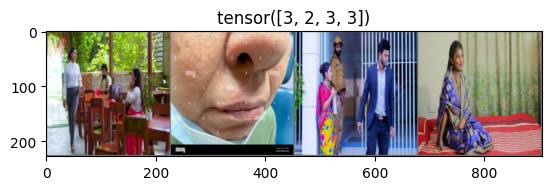

In [15]:
# ══════════════════════════════════════════════════════════════════════
# [셀 14] 학습 배치 샘플 시각화
# ══════════════════════════════════════════════════════════════════════
import builtins

# DataLoader는 파이썬 반복자(iterator)이므로 iter()로 변환 후 next()로 배치를 꺼냅니다.
# 주의: 'iter'를 변수명으로 사용하면 파이썬 내장 함수 iter()가 덮어씌워집니다.
#       builtins.iter()를 사용하면 내장 함수를 안전하게 호출할 수 있습니다.
train_iter = builtins.iter(train_loader)

# next(): 반복자에서 다음 배치 1개를 꺼냅니다.
#   imgs  → shape [4, 3, 224, 224]  (배치 4장, RGB, 224×224)
#   labels → shape [4]              (각 이미지의 클래스 인덱스)
imgs, labels = next(train_iter)

# torchvision.utils.make_grid: 여러 장의 이미지를 하나의 격자(grid)로 합칩니다.
#   nrow(기본값=8): 한 행에 배치할 이미지 수
#   반환 shape: (3, H, W_total) — 모든 이미지를 가로로 나열
out_imgs = torchvision.utils.make_grid(imgs)

# imshow(역정규화 + matplotlib 출력)
# title에 labels 텐서를 전달하면 정수 목록이 그래프 제목으로 표시됩니다.
imshow(out_imgs, labels)


---

## STEP 9 — 사전학습 모델 로드 (ConvNeXt-Small)

> **목적** : ImageNet으로 사전학습된 ConvNeXt-Small 을 불러와 전이학습의 출발점으로 삼습니다.

**ConvNeXt-Small 아키텍처 요약**

```
features[0]  →  Stem (Patch Embedding)   224×224 → 56×56
features[1]  →  Downsampling + LayerNorm
features[2]  →  Stage 1 ConvNeXt Blocks
features[3]  →  Downsampling + LayerNorm
features[4]  →  Stage 2 ConvNeXt Blocks
features[5]  →  Downsampling + LayerNorm
features[6]  →  Stage 3 ConvNeXt Blocks   ← Fine-Tuning 대상
features[7]  →  LayerNorm                 ← Fine-Tuning 대상
avgpool      →  Global Average Pooling
classifier   →  [0] LayerNorm  [1] Flatten  [2] Linear(768, 1000) ← 교체 대상
```

- 파라미터 수 : 약 **50M** (ImageNet Top-1 Acc. 83.1%)
- `weights=IMAGENET1K_V1` → 사전학습 가중치를 자동 다운로드 후 로드


In [16]:
# ══════════════════════════════════════════════════════════════════════
# [셀 15] 사전학습(Pretrained) ConvNeXt-Small 모델 로드
# ══════════════════════════════════════════════════════════════════════
# ConvNeXt: Microsoft Research가 2022년에 발표한 순수 CNN 기반 아키텍처로,
#           Vision Transformer(ViT)의 설계 원칙을 CNN에 접목한 모델입니다.
# ConvNeXt-Small: Tiny < Small < Base < Large < XLarge 중 두 번째 크기
#   파라미터 수: 약 50M  (ResNet-34 ≈ 22M 대비 훨씬 강력)
#   ImageNet Top-1 Accuracy: 83.1% (IMAGENET1K_V1 기준)
#
# weights=ConvNeXt_Small_Weights.IMAGENET1K_V1:
#   ImageNet-1K(약 128만 장, 1000 클래스)으로 사전학습된 가중치를 로드합니다.
#   이 가중치는 edges, textures, shapes 등 다양한 시각적 특징을 이미 학습했으므로
#   소규모 데이터셋에 적용해도 높은 성능을 기대할 수 있습니다. (전이학습)
#
# 모델 구조 핵심:
#   features[0~7] : 7개 스테이지의 Downsampling + ConvNeXt Block (특징 추출기)
#   avgpool       : Global Average Pooling
#   classifier    : [0] LayerNorm, [1] Flatten, [2] Linear(768, 1000) ← 교체 대상
model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)
model


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [17]:
# ══════════════════════════════════════════════════════════════════════
# [셀 16] 모든 레이어의 학습 가능 여부(requires_grad) 확인
# ══════════════════════════════════════════════════════════════════════
# model.named_parameters(): (파라미터 이름, 파라미터 텐서) 쌍을 순서대로 순회합니다.
#   파라미터 이름 예시:
#     features.0.0.weight  → 첫 번째 Downsampling 레이어의 가중치
#     features.7.0.weight  → 마지막 LayerNorm 가중치
#     classifier.2.weight  → 출력 Linear 레이어 가중치
#
# requires_grad 의미:
#   True  → 역전파 시 이 파라미터에 대한 기울기(gradient) 계산 O → 가중치 업데이트 O
#   False → 기울기 계산 X → 학습 중 가중치 변경 없음 (동결/freeze 상태)
#
# 현재는 сеть를 처음 로드했으므로 모든 파라미터가 True입니다.
# 아래 셀에서 freeze를 적용한 후 다시 실행하면 False로 바뀐 것을 확인할 수 있습니다.
for name, module in model.named_parameters():
    print(name, module.requires_grad)


features.0.0.weight True
features.0.0.bias True
features.0.1.weight True
features.0.1.bias True
features.1.0.layer_scale True
features.1.0.block.0.weight True
features.1.0.block.0.bias True
features.1.0.block.2.weight True
features.1.0.block.2.bias True
features.1.0.block.3.weight True
features.1.0.block.3.bias True
features.1.0.block.5.weight True
features.1.0.block.5.bias True
features.1.1.layer_scale True
features.1.1.block.0.weight True
features.1.1.block.0.bias True
features.1.1.block.2.weight True
features.1.1.block.2.bias True
features.1.1.block.3.weight True
features.1.1.block.3.bias True
features.1.1.block.5.weight True
features.1.1.block.5.bias True
features.1.2.layer_scale True
features.1.2.block.0.weight True
features.1.2.block.0.bias True
features.1.2.block.2.weight True
features.1.2.block.2.bias True
features.1.2.block.3.weight True
features.1.2.block.3.bias True
features.1.2.block.5.weight True
features.1.2.block.5.bias True
features.2.0.weight True
features.2.0.bias Tru

---

## STEP 10 — Feature Extraction 설정 (Backbone 동결 + 헤드 교체)

> **목적** : 사전학습된 특징 추출기(Backbone)를 완전히 고정하고, 출력 레이어만 5-클래스용으로 교체합니다.

**전이학습 전략 비교**

| 항목          | Feature Extraction | Fine-Tuning (STEP 13)             |
| ------------- | ------------------ | --------------------------------- |
| 학습 파라미터 | `classifier[2]` 만 | `features[6,7]` + `classifier[2]` |
| 학습률        | `1e-4`             | `1e-5` (더 작게)                  |
| 학습 속도     | 빠름               | 느림                              |
| 기대 정확도   | 보통               | 더 높음                           |
| 과적합 위험   | 낮음               | 상대적으로 높음                   |

- `requires_grad = False` : 기울기 계산 비활성 → 가중치 동결(freeze)
- `nn.Linear(768, 5)` : ImageNet 1000-클래스 헤드 → 5-클래스 헤드로 교체


In [18]:
# ══════════════════════════════════════════════════════════════════════
# [셀 17] Feature Extraction — 사전학습 가중치 전체 동결(Freeze)
# ══════════════════════════════════════════════════════════════════════
# 전이학습(Transfer Learning) 전략은 크게 두 가지입니다.
#
# ① Feature Extraction (이번 셀)
#    사전학습된 특징 추출기(Backbone)를 완전히 고정하고
#    분류 헤드(classifier)만 새로 학습합니다.
#    장점: 학습 속도 빠름, 적은 데이터에서도 안정적
#    단점: 도메인이 크게 다를 경우 정확도 한계
#
# ② Fine-Tuning (이후 셀)
#    Backbone 일부(주로 마지막 몇 개 레이어)와 분류 헤드를 함께 학습합니다.
#    장점: 더 높은 정확도 기대 가능
#    단점: 학습 데이터 부족 시 과적합 위험, 더 많은 연산 필요
#
# 현재: 모든 파라미터를 False로 설정 → Backbone 완전 동결
# 이후 classifier[2] 레이어만 교체하면 해당 레이어는 기본값 True가 되어
# fc 레이어만 학습됩니다.
for params in model.parameters():
    params.requires_grad = False


In [19]:
# ══════════════════════════════════════════════════════════════════════
# [셀 18] Freeze 후 모델 구조 재확인
# ══════════════════════════════════════════════════════════════════════
# 파라미터를 동결한 직후 모델 구조를 다시 출력합니다.
# 현재 classifier[2]는 여전히 Linear(768, 1000) 상태입니다.
# → 다음 셀에서 이 레이어를 Linear(768, 5)로 교체합니다.
#
# 주목할 점: ConvNeXt의 classifier 구조
#   (0) LayerNorm: 특징 벡터를 정규화
#   (1) Flatten : 2D 특징맵 → 1D 벡터로 평탄화
#   (2) Linear  : 768차원 특징 → 클래스 수 출력 ← 교체 대상
model


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [20]:
# ══════════════════════════════════════════════════════════════════════
# [셀 19] 분류 헤드(classifier) 교체 — 5개 클래스 대응
# ══════════════════════════════════════════════════════════════════════
# ConvNeXt-Small의 원래 끝 레이어:
#   classifier[2] = Linear(in_features=768, out_features=1000)  ← ImageNet 1000 클래스
#
# 우리 과제는 5개 피부 질환 클래스이므로 out_features를 5로 교체합니다.
#   classifier[2] = Linear(in_features=768, out_features=5)
#
# 새로 생성된 Linear 레이어는 requires_grad=True(기본값)이므로,
# Backbone이 동결된 상태에서 이 레이어만 학습됩니다.
# 가중치는 Xavier(=Glorot) uniform 초기화로 자동 설정됩니다.
#
# 5개 클래스 대응표:
#   인덱스 0 → acne   (여드름)
#   인덱스 1 → eksim  (습진)
#   인덱스 2 → herpes (헤르페스)
#   인덱스 3 → panu   (어루러기)
#   인덱스 4 → rosacea(주사)
model.classifier[2] = nn.Linear(768, 5)
model


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

---

## STEP 11 — Feature Extraction 학습 루프

> **목적** : 동결된 Backbone 위에서 `classifier[2]` 만 학습합니다. 에포크마다 손실을 TensorBoard에 기록합니다.

features[0~7] → 엣지, 텍스처, 형태 등 시각적 특징을 추출하는 방법을 이미 알고 있음
↑ 이걸 새로 학습하려면 엄청난 데이터와 시간이 필요
classifier[2] → "이 특징들이 어떤 클래스인가?" 를 판단하는 부분
↑ 우리 5개 클래스에 맞게 이것만 새로 학습

**학습 1회(배치) 순서**

```
① optimizer.zero_grad()   이전 배치의 기울기 누적 초기화
② preds = model(img)      순전파 → 로짓(logit) 계산  shape: (batch, 5)
③ loss = criterion(preds, labels)   CrossEntropyLoss 계산
④ loss.backward()         역전파 → 기울기 계산
⑤ optimizer.step()        Adam 으로 파라미터 업데이트
```

- `optim.Adam(lr=1e-4)` : 모든 파라미터 등록, 단 freeze된 것은 실제론 업데이트 안 됨
- `torch.save(state_dict)` : 에포크마다 모델 가중치 저장 → 중단 시 복구 가능
- `tensorboard --logdir=runs` 명령으로 학습 손실 추이를 시각화 가능


In [31]:
# ══════════════════════════════════════════════════════════════════════
# [셀 20] Feature Extraction 방식 — 학습 루프
# ══════════════════════════════════════════════════════════════════════
import tqdm
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()

device = "cuda" if torch.cuda.is_available() else "cpu"

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 20

model = model.to(device)

count = 0

for epoch in range(epochs):
    running_loss = 0.0  # 에포크 누적 손실 초기화

    for img, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
        # 1) 기울기 초기화
        optimizer.zero_grad()

        # 2) 순전파(Forward Pass)
        #    preds shape: (batch_size, 5)
        preds = model(img.to(device))

        # 3) 손실 계산
        loss = criterion(preds, labels.to(device))

        # TensorBoard에 배치별 학습 손실 기록
        writer.add_scalar("Loss/train", loss, count)
        count += 1

        # 4) 역전파(Backward Pass)
        loss.backward()

        # 5) 파라미터 업데이트
        optimizer.step()

        running_loss += loss.item()  # 배치 손실 누적

    # 에포크 평균 손실 = 전체 배치 손실 합 / 배치 수
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1:02d} | 평균 Loss: {avg_loss:.4f}")

    # 체크포인트 저장
    torch.save(model.state_dict(), "convnext_model.pth")

    writer.flush()


Epoch 1/20:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 68/68 [00:15<00:00,  4.28it/s]


Epoch 01 | 평균 Loss: 0.3008


Epoch 2/20: 100%|██████████| 68/68 [00:18<00:00,  3.67it/s]


Epoch 02 | 평균 Loss: 0.2932


...

Epoch 18 | 평균 Loss: 0.1928


Epoch 19/20: 100%|██████████| 68/68 [00:18<00:00,  3.70it/s]


Epoch 19 | 평균 Loss: 0.1867


Epoch 20/20: 100%|██████████| 68/68 [00:18<00:00,  3.67it/s]

Epoch 20 | 평균 Loss: 0.1824


---

## STEP 12 — Feature Extraction 모델 평가

> **목적** : 테스트셋으로 학습된 모델의 정확도를 측정하고, 예측 결과를 이미지와 함께 시각화합니다.

**평가 시 주의사항**

| API                      | 역할                                            |
| ------------------------ | ----------------------------------------------- |
| `model.eval()`           | Dropout · BatchNorm 을 추론 모드로 전환         |
| `torch.no_grad()`        | 기울기 계산 그래프 생성 안 함 → 메모리 절약     |
| `torch.max(preds, 1)[1]` | 가장 높은 점수의 클래스 인덱스 (예측 결과) 추출 |

$$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total test samples}}$$


tensor([3, 3, 1, 0])


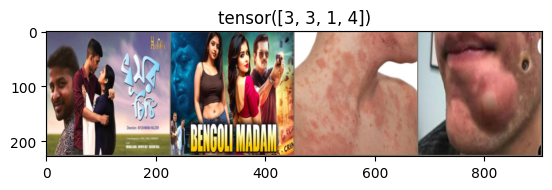

tensor([2, 0, 3, 4])


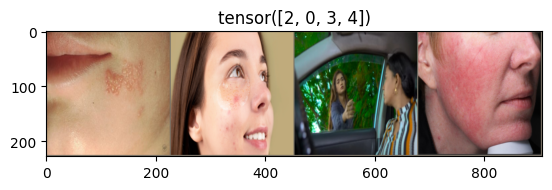

tensor([0, 3, 4, 4])


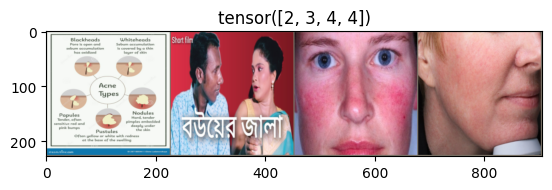

tensor([3, 1, 0, 0])


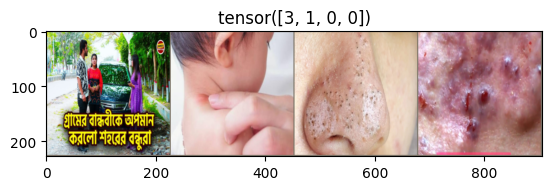

tensor([4, 0, 3, 3])


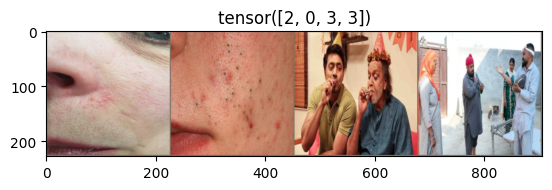

tensor([0, 2, 1, 2])


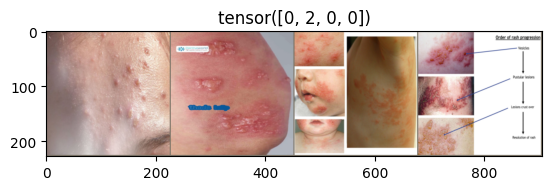

tensor([0, 1, 0, 2])


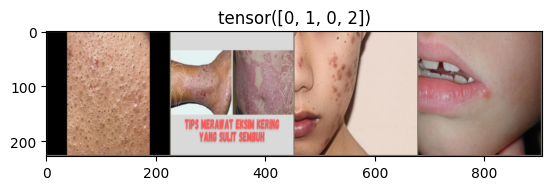

tensor([0, 3, 0, 1])


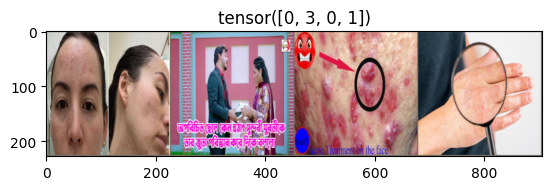

tensor([1, 2, 2, 0])


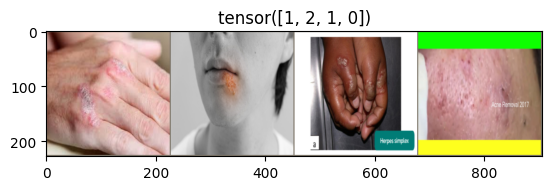

tensor([0, 1, 1, 3])


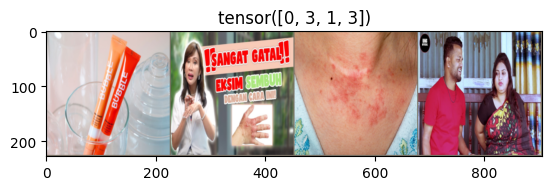

tensor([1, 4, 0, 3])


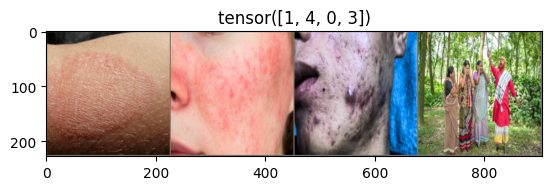

tensor([3, 2, 0, 3])


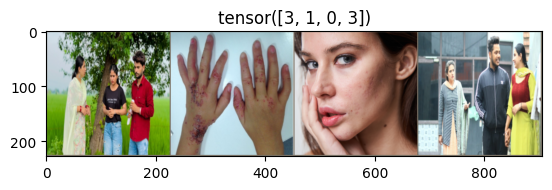

tensor([1, 3, 1, 3])


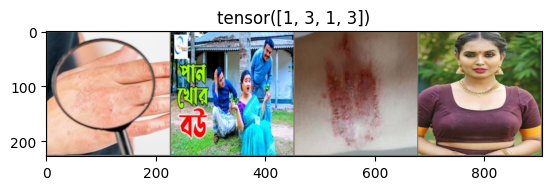

tensor([1, 3, 3, 3])


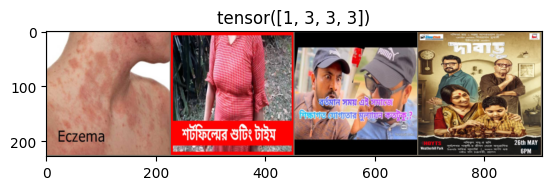

tensor([4, 4, 2, 3])


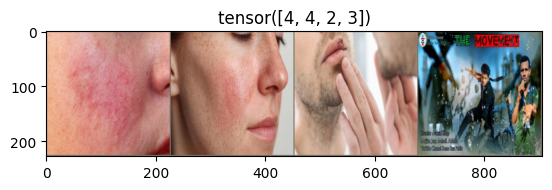

tensor([4, 0, 4, 3])


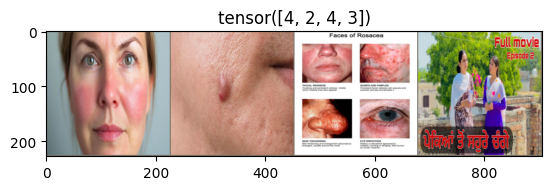

tensor([4, 3, 2, 0])


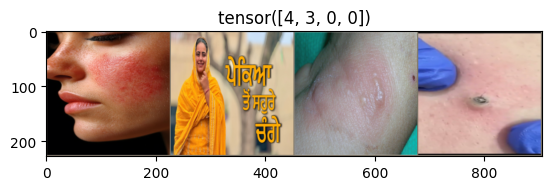

tensor([2, 2, 3, 1])


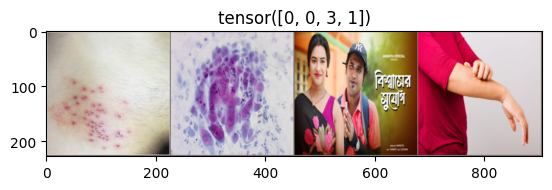

정확도 :  0.8333 정답수/총개수 : 60 / 72


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# [셀 21] Feature Extraction 모델 — 테스트셋 평가 (정확도 + 시각화)
# ══════════════════════════════════════════════════════════════════════

# model.eval(): 평가 모드로 전환합니다.
#   - Dropout 레이어: 훈련 시 랜덤 비활성, 평가 시 전체 뉴런을 사용합니다.
#   - BatchNorm 레이어: 훈련 시 배치 통계 사용, 평가 시 저장된 이동 평균 사용합니다.
#   → 일관된 추론 결과를 위해 필수입니다.
model.eval()

# torch.no_grad(): 컨텍스트 내에서 기울기 계산 그래프를 생성하지 않습니다.
#   - 메모리 사용량 절감 (기울기 텐서 저장 불필요)
#   - 연산 속도 향상
#   - 추론/평가 시 항상 사용 권장
with torch.no_grad():
    corrects = 0  # 정답 맞춘 횟수 누적 변수

    for img, labels in test_loader:
        # 순전파: shape (batch, 5) 로짓 텐서 계산
        preds = model(img.to(device))

        # torch.max(tensor, dim) → (최대값, 최대값 인덱스)
        #   dim=1: 클래스 축(각 샘플에서 가장 높은 점수를 가진 클래스 인덱스) 추출
        #   [1]: 인덱스 텐서만 가져옵니다 (예측 클래스 번호)
        pred = torch.max(preds, 1)[1]

        # 예측 클래스와 실제 레이블이 일치한 개수를 누적합니다.
        # .item(): 단일 원소 텐서 → 파이썬 정수 변환 (메모리 효율)
        corrects += (pred == labels.to(device)).sum().item()

        # 배치 이미지 격자 생성 후 시각화
        img_grid = torchvision.utils.make_grid(img)
        print(labels)  # 정답 레이블 출력
        imshow(img_grid.cpu(), title=pred)  # 예측값을 제목으로 이미지 출력
        # .cpu(): 텐서를 GPU → CPU로 이동 (imshow는 CPU 텐서를 사용)

    # 최종 정확도 계산: 정답 수 / 전체 테스트 샘플 수
    # test_datasets.targets: 전체 테스트셋의 레이블 리스트
    acc = corrects / len(test_datasets.targets)
    print(
        f"정확도 :  {acc:.4f}, 정답수/총개수 : {corrects} / {len(test_datasets.targets)}"
    )


In [23]:
# ══════════════════════════════════════════════════════════════════════
# [셀 22] Feature Extraction 학습 완료 후 모델 구조 재확인
# ══════════════════════════════════════════════════════════════════════
# classifier[2]가 Linear(768, 5)로 교체되어 있는지 확인합니다.
# Fine-Tuning으로 넘어가기 전 현재 모델 상태를 파악하는 용도입니다.
model


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [24]:
# ══════════════════════════════════════════════════════════════════════
# [셀 23] Fine-Tuning 대상 레이어(features[6], features[7]) 상태 확인
# ══════════════════════════════════════════════════════════════════════
# ConvNeXt-Small의 features 모듈 구성:
#   features[0]: Stem (Patch Embedding) — 224×224 → 56×56 다운샘플
#   features[2]: Stage 1 ConvNeXt Blocks
#   features[4]: Stage 2 ConvNeXt Blocks
#   features[6]: Stage 3 ConvNeXt Blocks ← 마지막 스테이지, 의미적 특징 담당
#   features[1,3,5,7]: Downsampling + LayerNorm 레이어
#
# Fine-Tuning 전략: 마지막 스테이지(features[6])와
# 마지막 LayerNorm(features[7])만 unfreeze하여 학습합니다.
#   이유: 앞쪽 레이어는 범용적인 저수준 특징(엣지, 텍스처) 담당 → 동결 유지
#          뒤쪽 레이어는 태스크 특화 고수준 특징 담당 → 우리 데이터에 맞게 조정
#
# 현재 이 셀에서는 Feature Extraction 후의 상태(모두 False)를 확인합니다.
# features[6]과 features[7]을 unfreeze하기 전 초기 상태 점검 용도입니다.
print("=== features[6] ===")
for name, param in model.features[6].named_parameters():
    print(name, param.requires_grad)

print("=== features[7] ===")
for name, param in model.features[7].named_parameters():
    print(name, param.requires_grad)


=== features[6] ===
0.weight False
0.bias False
1.weight False
1.bias False
=== features[7] ===
0.layer_scale False
0.block.0.weight False
0.block.0.bias False
0.block.2.weight False
0.block.2.bias False
0.block.3.weight False
0.block.3.bias False
0.block.5.weight False
0.block.5.bias False
1.layer_scale False
1.block.0.weight False
1.block.0.bias False
1.block.2.weight False
1.block.2.bias False
1.block.3.weight False
1.block.3.bias False
1.block.5.weight False
1.block.5.bias False
2.layer_scale False
2.block.0.weight False
2.block.0.bias False
2.block.2.weight False
2.block.2.bias False
2.block.3.weight False
2.block.3.bias False
2.block.5.weight False
2.block.5.bias False


---

## STEP 13 — Fine-Tuning (마지막 스테이지 + 헤드 함께 학습)

> **목적** : Feature Extraction 으로 얻은 성능보다 더 높은 정확도를 위해, 마지막 ConvNeXt 스테이지(`features[6,7]`)와 분류 헤드를 함께 학습합니다.

**Fine-Tuning 구성**

```
고정 (freeze)   : features[0] ~ features[5]   저수준 범용 특징 보존
학습 (unfreeze) : features[6]                 고수준 의미적 특징 조정
                 features[7]                 최종 LayerNorm 조정
                 classifier[2]               5-클래스 분류 헤드
```

**학습 전략**

- `lr=1e-5` : Feature Extraction(1e-4) 보다 10배 작은 학습률 → 사전학습 특징 미세 조정
- `filter(lambda p: p.requires_grad, ...)` : unfreeze 된 파라미터만 옵티마이저에 등록
- 에포크마다 검증 정확도 계산 → 최고 정확도 시 `convnext_finetune_best.pth` 저장
- 매 에포크 `checkpoint_epoch{n}.pth` 저장 → 학습 재개(resume) 가능


In [34]:
# ══════════════════════════════════════════════════════════════════════
# [셀 24] Fine-Tuning — 모델 재구성 및 전체 학습 루프
# ══════════════════════════════════════════════════════════════════════
# Feature Extraction vs Fine-Tuning 비교
# ┌────────────────────┬──────────────────────┬───────────────────────┐
# │                    │  Feature Extraction  │      Fine-Tuning      │
# ├────────────────────┼──────────────────────┼───────────────────────┤
# │ 학습 파라미터       │ classifier[2] 만     │ features[6,7] +       │
# │                    │                      │ classifier[2]         │
# │ 학습률             │ 1e-4                 │ 1e-5 (더 작게)        │
# │ 기대 정확도         │ 보통                 │ 더 높음               │
# │ 과적합 위험         │ 낮음                 │ 상대적으로 높음       │
# └────────────────────┴──────────────────────┴───────────────────────┘

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── 1) 사전학습 모델 재로드 ───────────────────────────────────────────
# Feature Extraction 학습으로 classifier[2]가 이미 업데이트된 상태이므로
# 공정한 비교를 위해 사전학습 가중치를 새로 로드합니다.
model_ft = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)

# ── 2) 전체 Backbone 동결 ─────────────────────────────────────────────
for param in model_ft.parameters():
    param.requires_grad = False

# ── 3) 마지막 스테이지만 선택적 Unfreeze ─────────────────────────────
# features[6]: 4개의 ConvNeXt Block으로 구성된 마지막 스테이지
#   고수준 의미 특징(semantic feature)을 담당하며, 피부 질환 특징 학습에 효과적
# features[7]: 마지막 LayerNorm (특징 정규화 후 classifier로 전달)
for param in model_ft.features[6].parameters():
    param.requires_grad = True
for param in model_ft.features[7].parameters():
    param.requires_grad = True

# ── 4) 분류 헤드 교체 (5개 클래스) ───────────────────────────────────
model_ft.classifier[2] = nn.Linear(768, 5)
model_ft = model_ft.to(device)

# ── 5) Fine-Tuning 학습 설정 ──────────────────────────────────────────
writer_ft = SummaryWriter()

# filter(lambda p: p.requires_grad, ...): requires_grad=True인 파라미터만 옵티마이저에 등록
# lr=1e-5: Fine-Tuning 시 매우 작은 학습률 → 사전학습 특징을 조금씩만 조정
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()), lr=1e-5
)
criterion_ft = nn.CrossEntropyLoss()
epochs_ft = 20

best_acc = 0.0  # 전체 에포크 중 가장 높은 검증 정확도 저장용
count_ft = 0  # TensorBoard 스텝 카운터

for epoch in range(epochs_ft):
    # ── 훈련 단계(Train) ────────────────────────────────────────────
    # model.train(): Dropout/BatchNorm을 학습 모드로 전환
    model_ft.train()
    running_loss = 0.0

    for img, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs_ft}"):
        optimizer_ft.zero_grad()

        preds = model_ft(img.to(device))
        loss = criterion_ft(preds, labels.to(device))

        # TensorBoard에 배치별 손실 기록
        writer_ft.add_scalar("FineTune/Loss_train", loss.item(), count_ft)
        count_ft += 1

        loss.backward()
        optimizer_ft.step()
        running_loss += loss.item()

    # ── 검증 단계(Validation) ───────────────────────────────────────
    # 매 에포크 끝에 테스트셋으로 검증 정확도를 계산합니다.
    # → 과적합 여부를 모니터링하고 최적 모델을 저장합니다.
    model_ft.eval()
    corrects_ft = 0
    with torch.no_grad():
        for img, labels in test_loader:
            preds = model_ft(img.to(device))
            pred = torch.max(preds, 1)[1]
            corrects_ft += (pred == labels.to(device)).sum().item()

    epoch_acc = corrects_ft / len(test_datasets.targets)
    avg_loss = running_loss / len(train_loader)

    writer_ft.add_scalar("FineTune/Acc_val", epoch_acc, epoch)
    print(f"Epoch {epoch + 1:02d} | Loss: {avg_loss:.4f} | Val Acc: {epoch_acc:.4f}")

    # ── Best 모델 저장 ──────────────────────────────────────────────
    # 이전 에포크보다 검증 정확도가 높을 때만 저장합니다.
    # → 마지막 에포크가 아닌 진짜 "가장 좋은" 모델을 보존합니다.
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model_ft.state_dict(), "convnext_finetune_best.pth")
        print(f"  → Best model saved (acc={best_acc:.4f})")

    # ── 체크포인트 저장 ──────────────────────────────────────────────
    # 에포크마다 상태 딕셔너리 전체를 저장합니다.
    # optimizer_state_dict도 함께 저장하면 이 시점부터 학습 재개 가능합니다.
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model_ft.state_dict(),
            "optimizer_state_dict": optimizer_ft.state_dict(),
            "loss": avg_loss,
            "acc": epoch_acc,
        },
        f"convnext_finetune_checkpoint_epoch{epoch + 1}.pth",
    )

writer_ft.flush()
print(f"\nFine-Tuning 완료 | Best Val Acc: {best_acc:.4f}")


Epoch 1/20: 100%|██████████| 68/68 [00:19<00:00,  3.52it/s]


Epoch 01 | Loss: 1.5593 | Val Acc: 0.4861
  → Best model saved (acc=0.4861)


Epoch 2/20: 100%|██████████| 68/68 [00:24<00:00,  2.78it/s]


Epoch 02 | Loss: 1.3376 | Val Acc: 0.6250
  → Best model saved (acc=0.6250)


Epoch 3/20: 100%|██████████| 68/68 [00:23<00:00,  2.84it/s]


...

Epoch 05 | Loss: 0.9284 | Val Acc: 0.6944


Epoch 6/20: 100%|██████████| 68/68 [00:22<00:00,  2.99it/s]


Epoch 06 | Loss: 0.8185 | Val Acc: 0.6806


Epoch 7/20: 100%|██████████| 68/68 [00:23<00:00,  2.88it/s]


KeyboardInterrupt: 

---

## STEP 14 — Grad-CAM 시각화

> **목적** : 학습이 완료된 모델이 예측 시 이미지의 "어느 영역"에 집중했는지 히트맵으로 시각화합니다.

**Grad-CAM 원리**
$$\alpha_k^c = \frac{1}{Z} \sum_{i} \sum_{j} \frac{\partial y^c}{\partial A_{ij}^k}$$
$$L_{\text{Grad-CAM}}^c = \text{ReLU}\!\left(\sum_k \alpha_k^c A^k\right)$$

- $A^k$ : 마지막 Conv 레이어의 k 번째 특징맵(feature map)
- $\alpha_k^c$ : 클래스 c 에 대한 k 번째 특징맵의 중요도 가중치
- 양수 영역만 남겨(ReLU) 해당 클래스와 관련 있는 공간 위치를 강조

| 모듈                     | 역할                              |
| ------------------------ | --------------------------------- |
| `GradCAM`                | 기울기 기반 클래스 활성화 맵 생성 |
| `show_cam_on_image`      | 원본 이미지 위에 히트맵 오버레이  |
| `ClassifierOutputTarget` | 시각화할 클래스 인덱스 지정       |


In [26]:
# ══════════════════════════════════════════════════════════════════════
# [셀 25] Grad-CAM 라이브러리 임포트
# ══════════════════════════════════════════════════════════════════════
# pytorch-grad-cam: CNN 모델의 예측 근거를 시각화하는 Grad-CAM 구현 라이브러리
# 설치: pip install grad-cam
#
# GradCAM: Gradient-weighted Class Activation Mapping
#   특정 클래스를 예측할 때 모델이 이미지의 "어느 부분"에 집중했는지 히트맵으로 표시
#   원리: 마지막 Conv 레이어의 활성화맵(feature map)에 해당 클래스의 기울기를
#         가중치로 적용하여 중요도 맵을 생성합니다.
#
# 주요 모듈:
#   GradCAM              : 기본 Grad-CAM 알고리즘 구현 클래스
#   show_cam_on_image    : 원본 이미지 위에 히트맵을 반투명하게 오버레이하는 유틸리티
#   ClassifierOutputTarget: 특정 클래스(인덱스)를 Grad-CAM 타겟으로 지정하는 클래스
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
